In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="2"

In [2]:
import torch
import k3d
import numpy as np
import matplotlib.pyplot as plt
import pickle

import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

from models.wire import ConditionalWIRE 
from util.visualization.utils_mesh import get_mesh
from training.residuals import ResidualLibrary, ResidualTerm, compute_loss

torch.manual_seed(0)

device = 'cpu' #if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device)

In [3]:
losses_over_time_dict = {}
weights_over_time_dict = {}
times_dict = {}
mesh_dict = {}

# keys = ["Adam_nostrain_", "GN_nostrain_linesearch_", "GN_strain_linesearch", "Adam_strain", "GN_strain[1e-5]_linesearch", "Adam_strain[1e-5]"]
# keys = ["Adam_nostrain_", "GN_nostrain_linesearch_"] 
# keys = ["GN_strain_linesearch", "Adam_strain"] ## effectively no strain so not so interesting
# keys = ["GN_strain[1e-5]_linesearch", "Adam_strain[1e-5]"] ## same as next
# keys = ["GN_strain[1e-5]_ph0iso0.1_linesearch", "Adam_strain[1e-5]_ph0iso0.1"]
## 14.08
# keys = ["GN_ph0iso0.1_linesearch_pre_4096eik_drsdf", "Adam_ph0iso0.1_lr3e-4_pre_4096eik_drsdf"] ## GOOD
# keys = ["GN_strain[1e-5]_ph0iso0.1_linesearch_pre_4096eik_drsdf", "Adam_strain[1e-5]_ph0iso0.1_lr3e-4_pre_4096eik_drsdf"] ## GOOD
# keys = ["Adam_strain[1e-5,max100]_ph0iso0.1_lr3e-4_pre_4096eik_drsdf", "Adam_strain[1e-5,max1000]_ph0iso0.1_lr3e-4_pre_4096eik_drsdf"]
keys = ["GN_strain[1e-5,max1000]_ph0iso0.1_linesearch_pre_4096eik_drsdf", "Adam_strain[1e-5,max1000]_ph0iso0.1_lr3e-4_pre_4096eik_drsdf"] ## GOOD
# keys = ["GN_strain[1e-4,max1000]_ph0iso0.1_linesearch_pre_4096eik_drsdf", "Adam_strain[1e-4,max1000]_ph0iso0.1_lr3e-4_pre_4096eik_drsdf"] ## GOOD

for key in keys:
    with open(f'{key}/losses_over_time.pkl', 'rb') as f:
        losses_over_time_dict[key] = pickle.load(f)

    with open(f'{key}/times.pkl', 'rb') as f:
        times_dict[key] = pickle.load(f)
        
    with open(f'{key}/weights_over_time.pkl', 'rb') as f:
        weights_over_time_dict[key] = pickle.load(f)

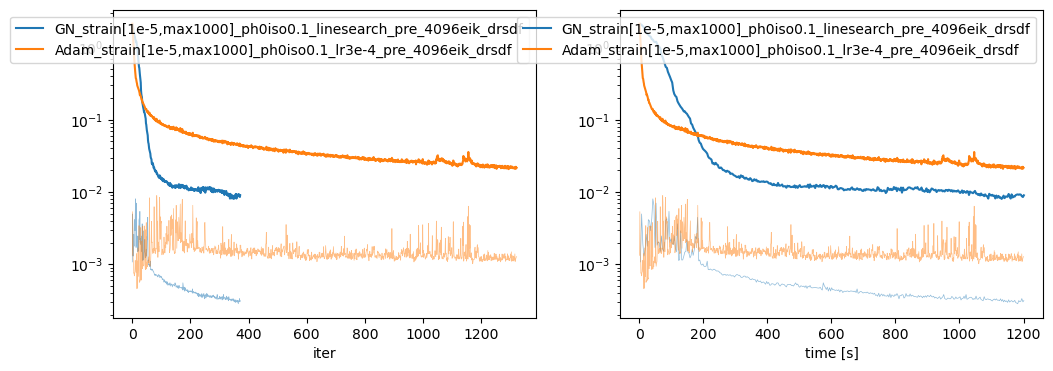

In [4]:
fig, axs = plt.subplots(1,2, figsize=(12,4))

for key in keys:
    losses_over_time = losses_over_time_dict[key]
    weights_over_time = weights_over_time_dict[key]
    times = times_dict[key]

    weighted_sum = np.sum([np.array(losses_over_time[k]) * np.array(weights_over_time[k]) for k in losses_over_time.keys()], axis=0)
    
    ## over iters
    axs[0].plot(weighted_sum, label=key)
    axs[0].legend()
    axs[0].set_xlabel("iter")
    axs[0].semilogy()

    ## over time
    axs[1].plot(times, weighted_sum, label=key)
    axs[1].legend()
    axs[1].set_xlabel("time [s]")
    axs[1].semilogy()
    
    
    k = "strain"
    # Use the same color as the weighted_sum line, but dotted
    color = axs[0].lines[-1].get_color()
    strain = np.array(losses_over_time[k]) * np.array(weights_over_time[k])
    axs[0].plot(strain, alpha=0.5, color=color, linewidth=0.5)
    axs[1].plot(times, strain, alpha=0.5, color=color, linewidth=0.5)

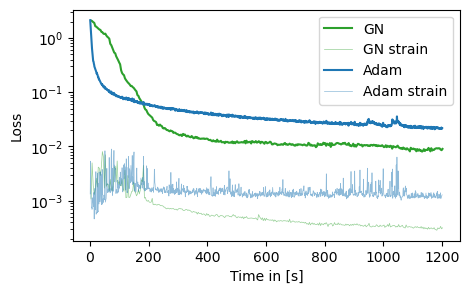

In [5]:
## Final plot
fig, ax = plt.subplots(1,1, figsize=(5,3))

for key in keys:
    losses_over_time = losses_over_time_dict[key]
    weights_over_time = weights_over_time_dict[key]
    times = times_dict[key]

    weighted_sum = np.sum([np.array(losses_over_time[k]) * np.array(weights_over_time[k]) for k in losses_over_time.keys()], axis=0)
    
    label = "Adam" if "Adam" in key else "GN"
    c = plt.get_cmap('tab10')(0) if "Adam" in key else plt.get_cmap('tab10')(2)
    
    ## over time
    ax.plot(times, weighted_sum, label=label, c=c)
    ax.set_xlabel("Time in [s]")
    ax.set_ylabel("Loss")
    ax.semilogy()
    
    
    k = "strain"
    strain = np.array(losses_over_time[k]) * np.array(weights_over_time[k])
    ax.plot(times, strain, alpha=0.5, color=ax.lines[-1].get_color(), linewidth=0.5, label=f"{label} strain")
    
    ax.legend()

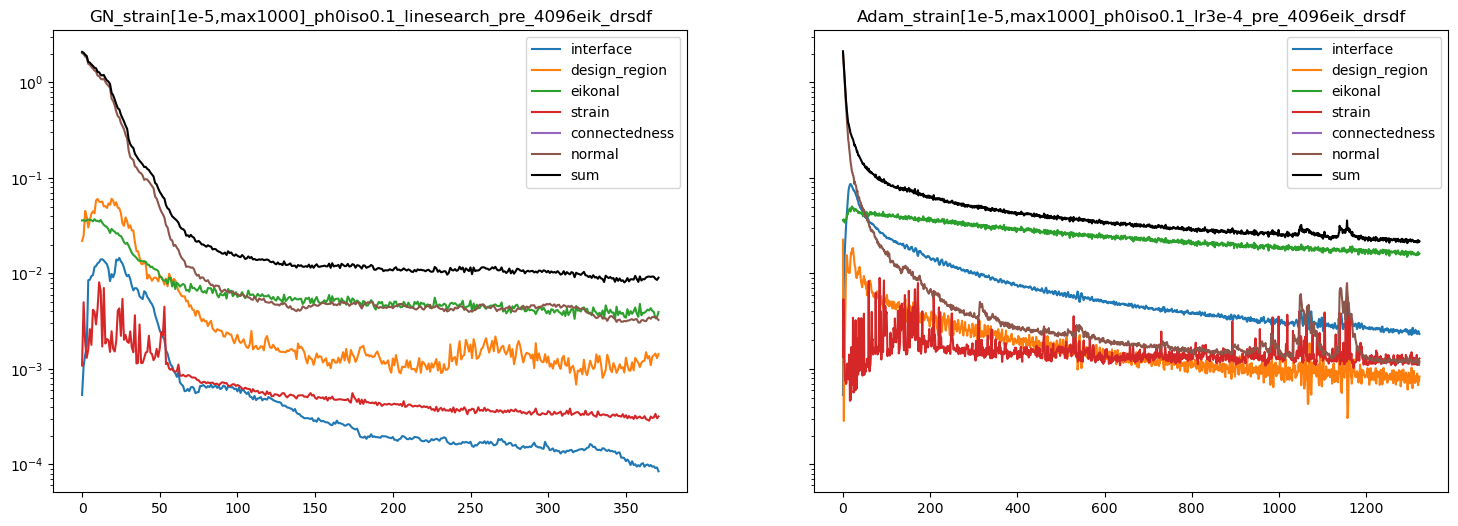

In [6]:
fig, axs = plt.subplots(1,2, figsize=(18,6), sharey=True)
for key, ax in zip(keys, axs):
    losses_over_time = losses_over_time_dict[key]
    weights_over_time = weights_over_time_dict[key]
    
    for k, v in losses_over_time.items():
        ax.plot(np.array(v)*np.array(weights_over_time[k]), label=k)
    weighted_sum = np.sum([np.array(losses_over_time[k]) * np.array(weights_over_time[k]) for k in losses_over_time.keys()], axis=0)
    ax.plot(weighted_sum, c='k', label="sum")
    ax.legend()
    ax.semilogy()
    ax.set_title(f"{key}")
plt.show()

### Plot shapes

In [7]:

# strain_modified = lambda *args : torch.clamp(res_lib._strain(*args), max=1e3)

In [ ]:
model = ConditionalWIRE([4, 32, 32, 32, 1], False, 18, 1, 6)
key = keys[1]
model.load_state_dict(torch.load(f"{key}/model.pt", map_location=device))
print(key)
bounds = torch.from_numpy(np.load('../Data JEB/bounds.npy')).float()


model = model.double()
f = lambda x : model(x, 0.05+torch.zeros([len(x), 1], dtype=torch.float64) )
verts, faces = get_mesh(
    f, 
    N=128, 
    device=device,
    bbox_min=bounds[:,0],
    bbox_max=bounds[:,1],
    chunks=1
)

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
## with surface strain colormap
from torch.func import vmap
res_lib = ResidualLibrary(model)
params = dict(model.named_parameters())
strains = vmap(res_lib._strain, in_dims=(None, 0))(params, torch.tensor(verts, dtype=torch.float64)).squeeze().detach().cpu()
fig += k3d.mesh(verts, faces, attribute=strains.log(), side='double', flat_shading=False)

# fig += k3d.mesh(mesh_env.vertices, mesh_env.faces, color=0xbb0000, opacity=0.3)
# fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False, attribute=is_inside_envelope(torch.from_numpy(verts)))

fig += k3d.text2d(key.replace('_', r'\_'), position=(0.5, 0), reference_point='ct', label_box=False, color=0x000000)
fig.display()

GN_strain[1e-5,max1000]_ph0iso0.1_linesearch_pre_4096eik_drsdf


/opt/homebrew/Caskroom/miniforge/base/envs/ginns/lib/python3.12/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "int32" does not match required type "uint32". A coerced copy has been created.
  warnings.warn(


Output()

In [18]:
fig_output_file = "../../docs/k3d_plot_jeb_gn.html"
with open(fig_output_file, 'w') as f:
    f.write(fig.get_snapshot())
print(f"Plot saved to {fig_output_file}")

Plot saved to ../../docs/k3d_plot_jeb_gn.html


In [9]:
def rotate_vertices(verts, angles, degrees=True, center=None, order="zyx"):
    """
    Rotate 3D points by Euler angles.

    Parameters
    ----------
    verts : (N, 3) array_like
        Input points (each row is x,y,z).
    angles : tuple/list of 3
        (roll_x, pitch_y, yaw_z) in radians by default; set degrees=True for degrees.
    degrees : bool, default True
        If True, interpret angles in degrees.
    center : (3,) array_like or None, default None
        Rotation center. If None, uses centroid of verts.
    order : str, default "zyx"
        Extrinsic rotation order (applied right-to-left to row vectors).
        Common choices: "zyx" (yaw→pitch→roll), "xyz", etc.

    Returns
    -------
    rotated : (N, 3) ndarray
        Rotated points.
    R : (3, 3) ndarray
        Rotation matrix used (so that rotated = (verts - c) @ R.T + c).
    """
    V = np.asarray(verts, dtype=float)
    assert V.ndim == 2 and V.shape[1] == 3, "verts must be (N,3)"
    rx, ry, rz = angles
    if degrees:
        rx, ry, rz = np.deg2rad([rx, ry, rz])

    # Basic right-handed rotation matrices
    cx, sx = np.cos(rx), np.sin(rx)
    cy, sy = np.cos(ry), np.sin(ry)
    cz, sz = np.cos(rz), np.sin(rz)

    Rx = np.array([[1, 0,  0],
                   [0, cx, -sx],
                   [0, sx,  cx]])

    Ry = np.array([[ cy, 0, sy],
                   [  0, 1,  0],
                   [-sy, 0, cy]])

    Rz = np.array([[cz, -sz, 0],
                   [sz,  cz, 0],
                   [ 0,   0, 1]])

    # Compose according to 'order' string for extrinsic rotations on row vectors
    mats = {'x': Rx, 'y': Ry, 'z': Rz}
    R = np.eye(3)
    for ax in order.lower():
        R = mats[ax] @ R  # left-multiply to apply in listed order

    c = np.asarray(center, dtype=float) if center is not None else V.mean(axis=0)
    rotated = (V - c) @ R.T + c
    return rotated, R


In [10]:
## FINAL
fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)

model = ConditionalWIRE([4, 32, 32, 32, 1], False, 18, 1, 6)


for i, key in enumerate(keys):
    shift = i*(bounds[:,1] - bounds[:,0]).numpy() * np.array([0, 1, 0])
    
    model.load_state_dict(torch.load(f"{key}/model.pt", map_location=device))
    print(key)
    bounds = torch.from_numpy(np.load('../Data JEB/bounds.npy')).float()

    model = model.double()
    f = lambda x : model(x, 0.05+torch.zeros([len(x), 1], dtype=torch.float64) )
    verts, faces = get_mesh(
        f, 
        N=128, 
        device=device,
        bbox_min=bounds[:,0],
        bbox_max=bounds[:,1],
        chunks=1
    )


    ## with surface strain colormap
    res_lib = ResidualLibrary(model)
    params = dict(model.named_parameters())
    strains = vmap(res_lib._strain, in_dims=(None, 0))(params, torch.tensor(verts, dtype=torch.float64)).squeeze().detach().cpu()
    verts, _ = rotate_vertices(verts, angles=(0, 45, 45), degrees=True, center=None, order="zyx")
    fig += k3d.mesh(verts + shift, faces, attribute=strains.log10(), side='double', flat_shading=False, color_map=k3d.basic_color_maps.Jet)


fig.display()

GN_strain[1e-5,max1000]_ph0iso0.1_linesearch_pre_4096eik_drsdf


/opt/homebrew/Caskroom/miniforge/base/envs/ginns/lib/python3.12/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "float64" does not match required type "float32". A coerced copy has been created.
  warnings.warn(


Adam_strain[1e-5,max1000]_ph0iso0.1_lr3e-4_pre_4096eik_drsdf


Output()

In [11]:
fig.camera = [179.57013825285867,
 16.861754263010912,
 28.508555182978604,
 0.07525430325780812,
 2.2904412163973675,
 0.5896307986890214,
 -0.10001274891484208,
 0.018586958080434077,
 0.9948125326129604]